In [3]:
!pip install ultralytics opencv-python matplotlib
!pip install git+https://github.com/openai/CLIP.git

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
  Cloning https://github.com/openai/CLIP.git to C:\Users\Shubh\AppData\Local\Temp\pip-req-build-bedukgam
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for clip: filename=clip-1.0-py3-none-any.whl size=1369631 sha256=bfccf30c436c78003bd3b590c20cc78c61c1bffae89a96b3a6322e8cb78f869e
  Stored in directory: C:\Users\Shubh\AppData\Local\Temp\pip-ephem-wheel-cache-2tvuwgb7\wheels\cb\a8\74\5f32d6cf0407457f0f62737b6da5c14eb86b9cac476fdf630d
Successfull

  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\Shubh\AppData\Local\Temp\pip-req-build-bedukgam'



image 1/1 c:\Users\Shubh\Desktop\SMAI\Assignment 3\grape.jpg: 576x640 1 grapes, 45.0ms
Speed: 4.9ms preprocess, 45.0ms inference, 3.2ms postprocess per image at shape (1, 3, 576, 640)


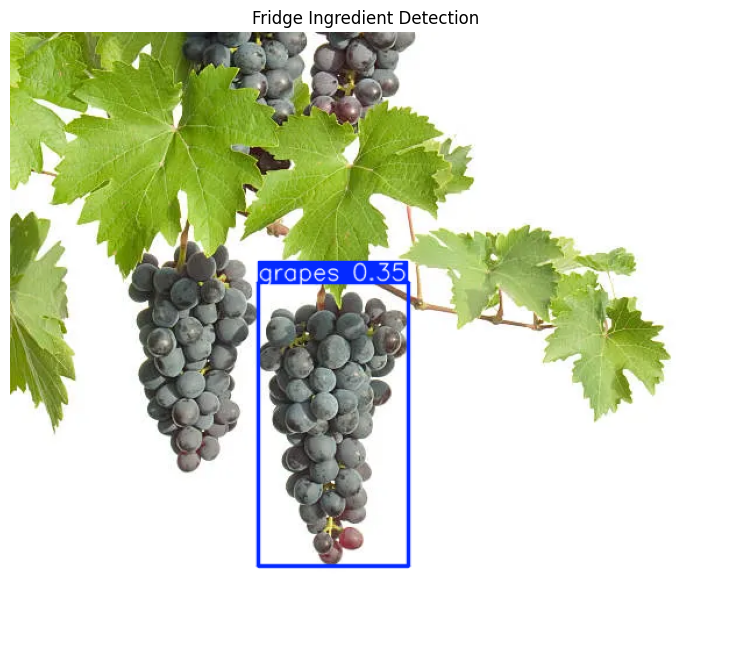

Ultralytics 8.4.37  Python-3.13.13 torch-2.7.1+cu118 CPU (AMD Ryzen 5 3550H with Radeon Vega Mobile Gfx)
WARNING YOLOWorld (original version) export is not supported to any format. YOLOWorldv2 models (i.e. 'yolov8s-worldv2.pt') only support export to (torchscript, onnx, openvino, engine, coreml) formats. See https://docs.ultralytics.com/models/yolo-world for details.
WARNING INT8 export requires a missing 'data' arg for calibration. Using default 'data=coco8.yaml'.

PyTorch: starting from 'yolov8s-worldv2.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 5, 8400) (24.7 MB)
requirements: Ultralytics requirement ['tensorflow>=2.0.0,<=2.19.0'] not found, attempting AutoUpdate...
WARNING Retry 1/2 failed: Command 'uv pip install --no-cache-dir --python "C:\Users\Shubh\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe" "tensorflow>=2.0.0,<=2.19.0"  --index-strategy=unsafe-best-match --break-system-packages' returned non-zero e

ModuleNotFoundError: No module named 'tensorflow'

In [9]:
import cv2
from ultralytics import YOLOWorld
from matplotlib import pyplot as plt

# 1. Load the model (Small version is best for mobile testing)
model = YOLOWorld('yolov8s-worldv2.pt')

# 2. Define your custom ingredient list
# This replaces the generic COCO classes with your specific food items
ingredients = ['grapes']
model.set_classes(ingredients)

# 3. Run detection on an image
# Replace 'fridge_test.jpg' with your actual image path
results = model.predict('grape.jpg', conf=0.25)

# 4. Visualize the results
for result in results:
    # Plotting the results using matplotlib for the notebook interface
    res_plotted = result.plot()
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(res_plotted, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title("Fridge Ingredient Detection")
    plt.show()

# 5. Exporting for Mobile (The "Phone" Step)
# This creates a TFLite model that you can move to an Android project
# Use 'format=coreml' if you are targeting iOS
model.export(format='tflite', int8=True)